In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np 
from numpy.fft import fft2, fftshift
from matplotlib.colors import LightSource
import warnings
warnings.filterwarnings('ignore')
from PIL import Image
import cv2
import scipy
from scipy import ndimage
from scipy.signal import medfilt
from scipy.signal import find_peaks
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation as Rot
from scipy.signal import medfilt
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LinearRegression
from matplotlib.ticker import ScalarFormatter


from ultralytics import YOLO
import torch
import tensorflow as tf
from keras.models import Sequential
from keras.layers.core import Flatten, Dense, Dropout
from keras.optimizers import Adam

In [ ]:
weight_folder = "AdressTo\Final_Weights_Publication"
image_folder = "AdressTo\Test_case_200_R2"
calibration_image_path = "AdressTo\Calib_grid.jpg"  # Replace with your image path
delH = 2.317929200680996e-07
delT = 5
rho_oil = 960
mu_cSt = 20 #21.86
mu_oil = mu_cSt * rho_oil * 1e-6

In [4]:
# Import YOLO
model_YOLO = YOLO(weight_folder + '\\YOLOFinall_pre_med_30Epo.pt')

# Import VGG16
input_shape = (200, 50, 1)
base_model = tf.keras.applications.VGG16(
    input_shape=input_shape,
    include_top=False,  # Exclude classification layer
    weights=None  
)

model = Sequential([
    base_model,
    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='linear'),  # Adjust activation as needed
])
learning_rate = 0.00001
model.compile(loss = 'mae',
              optimizer = Adam(learning_rate))  # Use mean squared error for regression  mae

model.summary()
model.load_weights(weight_folder + f"\VGG16Finall.h5")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 6, 1, 512)         14713536  
                                                                 
 flatten (Flatten)           (None, 3072)              0         
                                                                 
 dense (Dense)               (None, 4096)              12587008  
                                                                 
 dropout (Dropout)           (None, 4096)              0         
                                                                 
 dense_1 (Dense)             (None, 4096)              16781312  
                                                                 
 dropout_1 (Dropout)         (None, 4096)              0         
                                                                 
 dense_2 (Dense)             (None, 1)                 4

In [5]:
def calculate_max_magnitude_spectrum(image):

    pixel_data = np.array(image)
    
    magnitude_spectrum = np.abs(fftshift(fft2(pixel_data-np.mean(pixel_data))))
    center_index1_y = magnitude_spectrum.shape[0] // 2
    center_index1_x = magnitude_spectrum.shape[1] // 2
    center_vertical_line1 = magnitude_spectrum[center_index1_y:, center_index1_x]

    max_values_horizon = np.max(magnitude_spectrum[:center_index1_y - 5 , :], axis=1)
    max_value = np.max(max_values_horizon)

    return max_value

def replace_outliers_with_regression(X, y):
    # Ensure X and y are numpy arrays of float type to allow np.isnan to work
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float)
    
    # Create a mask for NaN values, which will be handled later
    nan_mask = np.isnan(y)
    
    # Fit the linear regression model only on the valid (non-NaN) data
    valid_mask = ~nan_mask
    X_valid = X[valid_mask]
    y_valid = y[valid_mask]
    
    # Fit linear regression on the valid data
    model = LinearRegression()
    model.fit(X_valid.reshape(-1, 1), y_valid)  # Reshape X for sklearn
    predictions = model.predict(X.reshape(-1, 1))  # Predict for all X, including the NaN values
    
    # Calculate the valid range (±5%)
    error = 0.05
    lower_bound = predictions * (1 - error)
    upper_bound = predictions * (1 + error)
    
    # Replace outliers with the predictions
    y_replaced = np.where(y > upper_bound, predictions, 
                          np.where(y < lower_bound, predictions, y))
    
    # Replace NaN values with predictions for those droplets
    y_replaced[nan_mask] = predictions[nan_mask]
    
    return y_replaced

def smart_crop(image_data, y_position_numbers, x_position_numbers, crop_height=200, crop_width=50):
    image_height, image_width = image_data.shape[:2]
    
    # Ensure crop dimensions fit within the image
    if crop_height > image_height or crop_width > image_width:
        raise ValueError("Crop size exceeds image dimensions.")
    
    max_y_position = image_height - crop_height

    # Generate evenly spaced y positions
    y_positions = np.linspace(50, max_y_position, y_position_numbers).astype(int)
    x_position = int(image_width / 2 - crop_width / 2)

    max_peaks = -np.inf
    best_y_position = None

    for y_position in y_positions:
        # Crop the region of the image
        cropped_image = image_data[y_position:y_position + crop_height, x_position:x_position + crop_width]
        
        # Calculate the maximum magnitude spectrum (requires definition)
        largest_peaks = calculate_max_magnitude_spectrum(cropped_image)

        if largest_peaks is not None and largest_peaks > max_peaks:
            max_peaks = largest_peaks
            best_y_position = y_position
    
    # Return the best position found, or None if no valid position
    return best_y_position , x_position

# Mouse callback function
def mouse_click(event, x, y, flags, param):
    global clicked_points
    if event == cv2.EVENT_LBUTTONDOWN:
        # Scale back the clicked point to original size
        original_x = int(x / resize_scale)
        original_y = int(y / resize_scale)
        clicked_points.append((original_x, original_y))
        print(f"Point selected (original scale): {(original_x, original_y)}")
        # Show the point on the resized image
        cv2.circle(temp_resized_image, (x, y), 5, (0, 0, 255), -1)
        cv2.imshow("Click on the corners", temp_resized_image)

        # Once we have 4 points, proceed
        if len(clicked_points) == 4:
            cv2.destroyWindow("Click on the corners")

In [6]:
resize_scale = 0.25
pts = []
clicked_points = []

# Load the image
image = cv2.imread(calibration_image_path)

# Convert the image to grayscale (optional, if color isn't important)
img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Resize the image for display (to make it fit on the screen)
h, w = img.shape[:2]
resized_width = int(w * resize_scale)
resized_height = int(h * resize_scale)
temp_resized_image = cv2.resize(img, (resized_width, resized_height))

# Display the resized image and set the mouse callback for corner selection
cv2.imshow("Click on the corners", temp_resized_image)
cv2.setMouseCallback("Click on the corners", mouse_click)

# Wait for the user to click 4 points
print("Click on the four corners of the paper in clockwise order starting from the top-left.")
cv2.waitKey(0)

# Ensure exactly 4 points are clicked
if len(clicked_points) != 4:
    print("Error: You must click exactly 4 points!")
    exit()

Click on the four corners of the paper in clockwise order starting from the top-left.
Point selected (original scale): (2732, 1844)
Point selected (original scale): (3308, 1848)
Point selected (original scale): (3296, 2260)
Point selected (original scale): (2732, 2264)


px_to_m =  7.092198581560284e-05


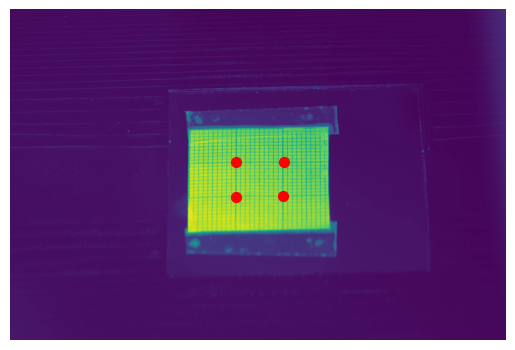

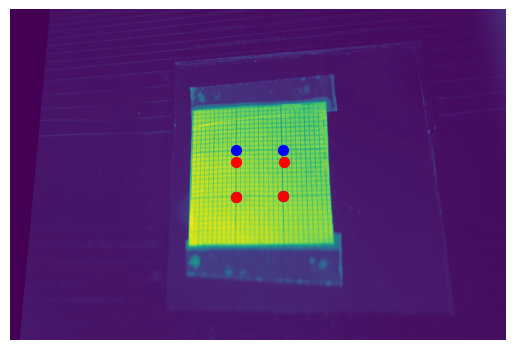

[[       2732        1700]
 [       3296        1696]
 [       3296        2260]
 [       2732        2264]]
[[       2732        1844]
 [       3308        1848]
 [       3296        2260]
 [       2732        2264]]


In [11]:
pts = np.array(clicked_points, dtype=np.float32)

delx = (pts[2,0]-pts[3,0])
px_to_m = 1e-2/delx / resize_scale
print('px_to_m = ' , px_to_m)

# Correctly forming the points for IPM matrix
ipm_pts = np.array([
    [pts[3, 0], pts[3, 1] - delx],  # Point 3, with adjusted y
    [pts[2, 0], pts[2, 1] - delx],  # Point 2, with adjusted y
    [pts[2, 0], pts[2, 1]],         # Point 2 without adjustment
    [pts[3, 0], pts[3, 1]]          # Point 3 without adjustment
], dtype=np.float32)


ipm_matrix = cv2.getPerspectiveTransform(pts, ipm_pts)
ipm = cv2.warpPerspective(img, ipm_matrix, img.shape[:2][::-1])

pts_x = [pt[0] for pt in pts]  # x-coordinates of points
pts_y = [pt[1] for pt in pts]  # y-coordinates of points
plt.scatter(pts_x, pts_y, color='red', marker='o', s=50, label='Points')
plt.imshow(img)
plt.axis('off') 
plt.show()

ipm_pts_x = [pt[0] for pt in ipm_pts]  # x-coordinates of points
ipm_pts_y = [pt[1] for pt in ipm_pts]  # y-coordinates of points
plt.scatter(ipm_pts_x, ipm_pts_y, color='blue', marker='o', s=50, label='Points')
plt.scatter(pts_x, pts_y, color='red', marker='o', s=50, label='Points')
plt.imshow(ipm)
plt.axis('off') 
plt.show()

# cv2.imwrite(r"C:\Bologna\Project\CICLoPE\Bachelor_Alessandro\OFI_AI\EXP_20241120\top_down_perspective.jpg", ipm)

In [8]:
# Configuration
crop_height = 200
crop_width = 50
max_width_factor = 6  # Maximum acceptable width as a multiple of crop_width
color_map = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255),
    (255, 255, 0), (0, 255, 255), (255, 0, 255)
]  # Colors for droplets
tracking_threshold = 50  # Maximum pixel difference for tracking droplets across frames
delT = 5  # Time increment between frames
# resize_scale = 0.25  # Resize factor for the display image

# Initialize data structures
fre_v = {}  # Stores frequencies for each droplet {1: [...], 2: [...], ...}
T_v, counts, T = [], 0, 0
tracked_droplets = {}  # Keeps track of droplet positions {1: x1, 2: x2, ...}

# Create a window to display images
cv2.namedWindow('Processed Image', cv2.WINDOW_NORMAL)

# Loop over image frames
for i in range(1, 121):
    filename = f"DSC_{i:04d}.jpg"
    img_path = os.path.join(image_folder, filename)
    im = cv2.imread(img_path)
    if im is None:
        print(f"Image {filename} not found, skipping.")
        continue

    # Preprocess the image
    im_gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    im_gray = cv2.warpPerspective(im_gray, ipm_matrix, im_gray.shape[::-1])
    im_gray = cv2.rotate(im_gray, cv2.ROTATE_90_CLOCKWISE)

    img_height, img_width = im_gray.shape[:2]
    min_dim = min(img_height, img_width)
    center_x, center_y = img_width // 2, img_height // 2
    start_x = center_x - min_dim // 2
    start_y = center_y - min_dim // 2
    end_x = start_x + min_dim
    end_y = start_y + min_dim
    im_gray = im_gray[start_y:end_y, start_x:end_x]

    im = cv2.merge([im_gray, im_gray, im_gray])

    # Resize the image for display
    display_height = int(im.shape[0] * resize_scale)
    display_width = int(im.shape[1] * resize_scale)
    im = cv2.resize(im, (display_width, display_height), interpolation=cv2.INTER_AREA)
    cv2.resizeWindow('Processed Image', display_width, display_height)

    # YOLO detection
    results = model_YOLO.predict(im, show=False)
    boxes = results[0].boxes.xyxy.cpu().tolist()
    box_centers = [(box, (box[0] + box[2]) / 2) for box in boxes]
    box_centers.sort(key=lambda x: x[1])  # Sort detected droplets by x-center

    # Match detected droplets with tracked positions
    matched_droplets = {}  # Map detected droplets to tracked IDs
    for box, center_x in box_centers:
        matched = False
        for droplet_id, tracked_x in tracked_droplets.items():
            if abs(center_x - tracked_x) < tracking_threshold:
                matched_droplets[droplet_id] = (box, center_x)
                tracked_droplets[droplet_id] = center_x  # Update position
                matched = True
                break
        if not matched:
            # Assign new ID if no match is found
            new_id = max(tracked_droplets.keys(), default=0) + 1
            matched_droplets[new_id] = (box, center_x)
            tracked_droplets[new_id] = center_x

    # Process each tracked droplet
    current_droplets = set()  # Droplets detected in this frame
    for droplet_id, (box, center_x) in matched_droplets.items():
        xmin, ymin, xmax, ymax = map(int, box)
        droplet_width = xmax - xmin
        droplet_height = ymax - ymin

        # Skip small or excessively large droplets
        if droplet_width < crop_width or droplet_height < crop_height:
            print(f"Droplet {droplet_id} in frame {filename} skipped: too small.")
            continue
        if droplet_width > max_width_factor * crop_width:
            print(f"Droplet {droplet_id} in frame {filename} skipped: too wide.")
            continue

        current_droplets.add(droplet_id)
        drop_img = cv2.cvtColor(im[ymin:ymax, xmin:xmax], cv2.COLOR_BGR2GRAY) / 256.0

        # Smart crop
        best_y, best_x = smart_crop(drop_img, 10, 10)
        ymin_int = ymin + best_y
        xmin_int = xmin + best_x
        xmax_int = xmin_int + crop_width
        ymax_int = ymin_int + crop_height

        # Draw bounding boxes
        color = color_map[(droplet_id - 1) % len(color_map)]  # Cycle through colors
        cv2.rectangle(im, (xmin, ymin), (xmax, ymax), color, 2)
        cv2.rectangle(im, (xmin_int, ymin_int), (xmax_int, ymax_int), color, 2)

        # Predict frequency
        int_img = im[ymin_int:ymax_int, xmin_int:xmax_int]
        int_img_gray = cv2.cvtColor(int_img, cv2.COLOR_BGR2GRAY) / 256.0
        int_img_final = np.expand_dims(int_img_gray, axis=(0, -1))

        fre = model.predict(int_img_final)
        fre_v.setdefault(droplet_id, []).append(fre[0, 0])

        # Annotate image
        prediction_text = f"Droplet {droplet_id}: {fre[0, 0]:.2f}"
        cv2.putText(im, prediction_text, (xmin_int - 250, ymin_int - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3)

    # Append `None` for missing droplets
    for droplet_id in tracked_droplets.keys():
        if droplet_id not in current_droplets:
            fre_v.setdefault(droplet_id, []).append(None)

    # Update time and counts
    counts += 1
    T += delT
    T_v.append(T)

    # Show the updated image
    cv2.imshow('Processed Image', im)
    if cv2.waitKey(0) == ord('q'):
        break

cv2.destroyAllWindows()


0: 640x640 3 droplets, 114.3ms
Speed: 15.0ms preprocess, 114.3ms inference, 2566.8ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 21ms/step

0: 640x640 3 droplets, 136.2ms
Speed: 533.4ms preprocess, 136.2ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 20ms/step

0: 640x640 3 droplets, 136.0ms
Speed: 720.0ms preprocess, 136.0ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 22ms/step

0: 640x640 3 droplets, 132.7ms
Speed: 5.0ms preprocess, 132.7ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 38ms/step

0: 640x640 3 droplets, 117.7ms
Speed: 6.0ms preprocess, 117.7ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 38ms/step

0: 640x640 3 droplets, 61.1ms
Speed: 6.0ms preprocess, 61.1ms inference, 3.0ms po

1/1 [==============================] - 0s 32ms/step

0: 640x640 3 droplets, 113.4ms
Speed: 5.9ms preprocess, 113.4ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 23ms/step

0: 640x640 3 droplets, 63.6ms
Speed: 5.0ms preprocess, 63.6ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 27ms/step

0: 640x640 3 droplets, 121.4ms
Speed: 6.1ms preprocess, 121.4ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 31ms/step

0: 640x640 3 droplets, 117.5ms
Speed: 5.9ms preprocess, 117.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 22ms/step

0: 640x640 3 droplets, 114.9ms
Speed: 6.1ms preprocess, 114.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 20ms/step

0: 640x640 3 droplets, 59.7ms
Speed: 5.

1/1 [==============================] - 0s 36ms/step

0: 640x640 3 droplets, 121.5ms
Speed: 6.1ms preprocess, 121.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 26ms/step

0: 640x640 3 droplets, 64.1ms
Speed: 5.0ms preprocess, 64.1ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 22ms/step

0: 640x640 3 droplets, 123.1ms
Speed: 6.0ms preprocess, 123.1ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 22ms/step

0: 640x640 3 droplets, 137.5ms
Speed: 6.2ms preprocess, 137.5ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 24ms/step

0: 640x640 3 droplets, 111.5ms
Speed: 6.4ms preprocess, 111.5ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 21ms/step

0: 640x640 3 droplets, 107.9ms
Speed: 6

1/1 [==============================] - 0s 22ms/step

0: 640x640 2 droplets, 111.6ms
Speed: 8.6ms preprocess, 111.6ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 20ms/step

0: 640x640 2 droplets, 56.8ms
Speed: 5.3ms preprocess, 56.8ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 23ms/step

0: 640x640 2 droplets, 113.3ms
Speed: 6.0ms preprocess, 113.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 30ms/step

0: 640x640 2 droplets, 57.3ms
Speed: 6.0ms preprocess, 57.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 20ms/step

0: 640x640 2 droplets, 116.6ms
Speed: 5.0ms preprocess, 116.6ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
1/1 [==============================] - 0s 21ms/step

0: 640x640 2 droplets, 57.2ms
Speed: 5.0m

In [9]:
# Initialize an empty dictionary to store filtered data by droplet_id
filtered_fre_v_dict = {}

# Iterate over each droplet in fre_v (now using droplet labels)
for droplet_id, fre_data in fre_v.items():
    # Convert fre_data to a NumPy array, replacing None with np.nan
    fre_data_array = np.array([np.nan if x is None else x for x in fre_data], dtype=float)
    
    # Check if all entries in fre_data_array are NaN
    if np.all(np.isnan(fre_data_array)):
        print(f"Droplet {droplet_id} has all None/NaN values and will be removed.")
        continue  # Skip this droplet if all values are NaN
        
        
    # Check and pad T_v and fre_data_array to make them the same length
    max_length = len(T_v)
    if len(fre_data_array) < max_length:
        fre_data_array = np.pad(fre_data_array, (0, max_length - len(fre_data_array)), constant_values=np.nan)
        
    # Replace outliers in the data
    filtered_fre_v = replace_outliers_with_regression(T_v, fre_data_array)
    
    # Store the filtered frequency data in the dictionary with the same droplet_id
    filtered_fre_v_dict[droplet_id] = filtered_fre_v
        
# print(fre_v)
# print(filtered_fre_v_dict)

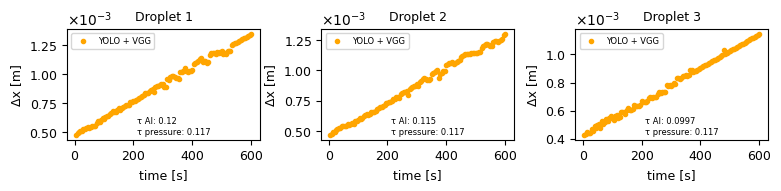

In [10]:
fnt_size = 9

# Perform linear regression
def calculate_metrics(T_v, fre_v, exclude_first, exclude_last):
    
    m, b = np.polyfit(np.asarray(T_v)[exclude_first:-exclude_last], fre_v[exclude_first:-exclude_last], 1)
    return m

# Function to create subplots for each droplet
def create_subplot(ax, T_v, fre_v, metrics, tau_pressure, title):
    
    fre_v = fre_v * px_to_m  # Convert to meters using px_to_m
    
    m = metrics
    ax.plot(np.asarray(T_v), np.asarray(fre_v), '.', label='YOLO + VGG', color='orange')
    ax.tick_params(axis='both', which='major', labelsize=fnt_size)
    ax.set_xlabel('time [s]', fontsize=fnt_size)
    ax.set_ylabel('Δx [m]', fontsize=fnt_size)
    ax.set_title(title, fontsize=fnt_size)
    ax.yaxis.set_major_formatter(formatter)
    ax.text(0.36, 0.05, f"\nτ AI: {m*mu_oil/delH:.3}\nτ pressure: {tau_pressure:.3}",
            fontsize=fnt_size - 3, transform=ax.transAxes)
    ax.legend(fontsize=fnt_size - 3)

# Initialize plot
fig = plt.figure(figsize=(7.7, 1.7))

# Use ScalarFormatter to scale the axis ticks
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, -3))

# Iterate over each droplet in filtered_fre_v_dict (now using droplet IDs)
for droplet_id in filtered_fre_v_dict.keys():
    metrics = calculate_metrics(T_v, [x * px_to_m for x in filtered_fre_v_dict[droplet_id]], 1, 1)
    ax = fig.add_subplot(1, len(filtered_fre_v_dict[droplet_id]), droplet_id)
    create_subplot(ax, T_v, filtered_fre_v_dict[droplet_id], metrics, 0.117, f'Droplet {droplet_id}')
    ax.set_position([0.08 + (0.33 * (droplet_id - 1)), 0.23, 0.25, 0.65])


# Save the figure
# plt.savefig(image_folder + "\\finall_AI_Tau.png", dpi=300)
plt.show()